# SMS Classification: Ham vs Spam vs Smishing

Three-class text classification on the Mendeley **Balanced Dataset for Spam and Smishing Detection** ([vmg875v4xs](https://data.mendeley.com/datasets/vmg875v4xs/1)) — 10,191 English SMS messages, perfectly balanced (3,397 each).

We compare three model tiers under one fair evaluation harness:

1. **Classic ML** — TF-IDF (word + char n-grams) + engineered features, with Complement Naive Bayes, Logistic Regression, and Linear SVM.
2. **Gradient boosting** — XGBoost on SVD-reduced TF-IDF + engineered features.
3. **Fine-tuned DistilBERT** — transformer baseline.

The academic focus is the **Spam vs Smishing** confusion: Ham is trivially separable, the two malicious classes overlap in vocabulary, and lexical cues in the message text (phone-number and URL mentions, words like *claim* / *prize*) are what pull them apart.

> **Note:** the dataset's separate `URL`/`EMAIL`/`PHONE` flag columns are explored in the EDA but are **deliberately excluded as model features** — every model learns from the message text (and text-derived statistics) only.

## 1. Setup

In [1]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Device: Apple Silicon (mps), CUDA, or CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("Torch device:", DEVICE)

Torch device: mps


## 2. Load and sanity-check the data

In [2]:
# Resolve path whether the notebook runs from repo root or notebooks/
CANDIDATES = ["data/Dataset_10191.csv", "../data/Dataset_10191.csv"]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert DATA_PATH, "Dataset_10191.csv not found. Place it under data/ (see README)."

df = pd.read_csv(DATA_PATH)
assert df.shape == (10191, 5), f"Unexpected shape: {df.shape}"
assert set(df["LABEL"].unique()) == {"ham", "spam", "smishing"}, df["LABEL"].unique()
assert df.isnull().sum().sum() == 0, "Unexpected null values"
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df["LABEL"].value_counts())
df.head()

Shape: (10191, 5)
Columns: ['LABEL', 'TEXT', 'URL', 'EMAIL', 'PHONE']
LABEL
ham         3397
smishing    3397
spam        3397
Name: count, dtype: int64


,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,No,No,No
1,ham,Yay can't wait to party together!,No,No,No
2,ham,At what time are you coming.,No,No,No
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",No,No,Yes
4,ham,Yo you around? A friend of mine's lookin to pi...,No,No,No


## 3. Exploratory data analysis

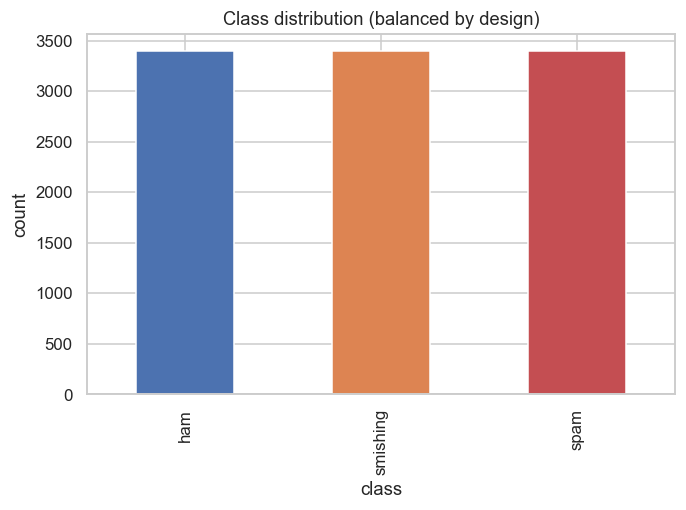

In [3]:
# 3.1 Class balance
ax = df["LABEL"].value_counts().sort_index().plot(kind="bar", color=["#4c72b0", "#dd8452", "#c44e52"])
ax.set_title("Class distribution (balanced by design)")
ax.set_xlabel("class"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

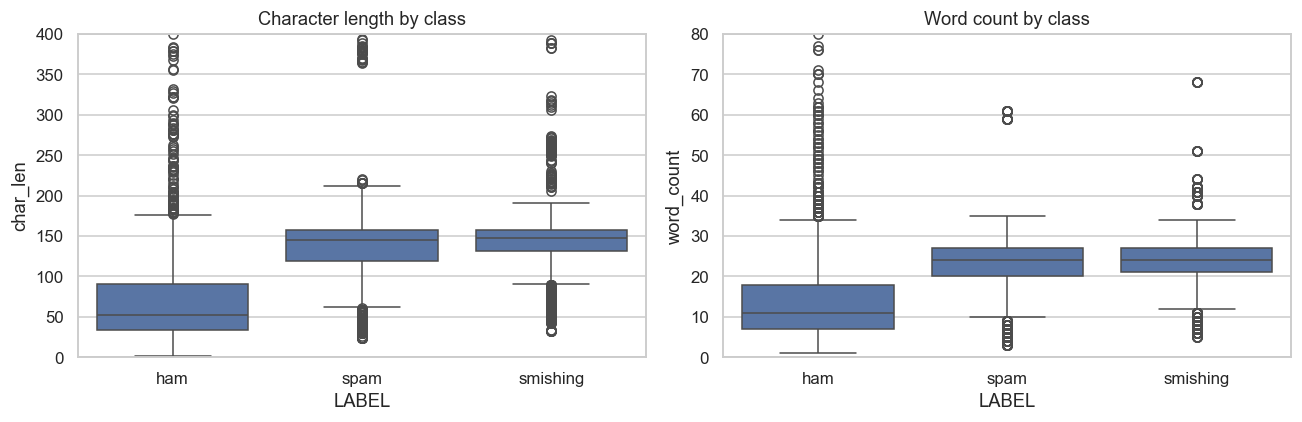

,char_len,word_count
LABEL,,
ham,52.0,11.0
smishing,147.0,24.0
spam,145.0,24.0


In [4]:
# 3.2 Message length per class
df["char_len"] = df["TEXT"].str.len()
df["word_count"] = df["TEXT"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="LABEL", y="char_len", order=["ham", "spam", "smishing"], ax=axes[0])
axes[0].set_title("Character length by class"); axes[0].set_ylim(0, 400)
sns.boxplot(data=df, x="LABEL", y="word_count", order=["ham", "spam", "smishing"], ax=axes[1])
axes[1].set_title("Word count by class"); axes[1].set_ylim(0, 80)
plt.tight_layout(); plt.show()

df.groupby("LABEL")[["char_len", "word_count"]].median()

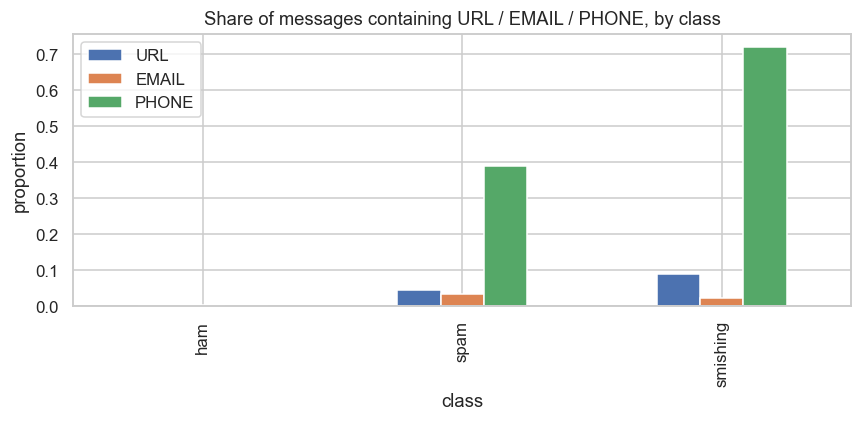

,URL,EMAIL,PHONE
LABEL,,,
ham,0.000,0.002,0.001
spam,0.046,0.032,0.390
smishing,0.089,0.022,0.721


In [5]:
# 3.3 Prevalence of URL / EMAIL / PHONE flags per class — the key discriminating signal
flag_rates = (df.assign(**{c: (df[c] == "Yes").astype(int) for c in ["URL", "EMAIL", "PHONE"]})
                .groupby("LABEL")[["URL", "EMAIL", "PHONE"]].mean())
ax = flag_rates.loc[["ham", "spam", "smishing"]].plot(kind="bar", figsize=(8, 4))
ax.set_title("Share of messages containing URL / EMAIL / PHONE, by class")
ax.set_ylabel("proportion"); ax.set_xlabel("class")
plt.tight_layout(); plt.show()
flag_rates.loc[["ham", "spam", "smishing"]].round(3)

In [6]:
# 3.4 Most distinctive tokens per class (raw text, English stopwords removed)
from sklearn.feature_extraction.text import CountVectorizer

for cls in ["ham", "spam", "smishing"]:
    cv = CountVectorizer(stop_words="english", min_df=5)
    X = cv.fit_transform(df.loc[df["LABEL"] == cls, "TEXT"])
    freqs = np.asarray(X.sum(axis=0)).ravel()
    top = pd.Series(freqs, index=cv.get_feature_names_out()).sort_values(ascending=False).head(12)
    print(f"[{cls}] {', '.join(top.index)}")

[ham] ok, lt, gt, just, ll, know, good, come, like, ur, got, day
[spam] free, txt, stop, ur, text, reply, mobile, www, nokia, week, tone, just
[smishing] customer, claim, free, prize, mobile, embody, urgent, 000, contact, www, dear, reply


## 4. Preprocessing

Deliberately **light**. We lowercase and normalize whitespace, but keep digits, punctuation, and currency. Raw URLs, emails, and phone numbers are collapsed to placeholder tokens (`__url__`, `__email__`, `__phone__`) — these are exactly the signals that separate smishing from ordinary spam, so we keep them as features instead of stripping them.

In [7]:
URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
EMAIL_RE = re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b")
PHONE_RE = re.compile(r"(\+?\d[\d\-\s().]{6,}\d)")

def clean_text(t):
    t = str(t).lower()
    t = URL_RE.sub(" __url__ ", t)
    t = EMAIL_RE.sub(" __email__ ", t)
    t = PHONE_RE.sub(" __phone__ ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["clean_text"] = df["TEXT"].apply(clean_text)

# Encode labels (alphabetical: ham=0, smishing=1, spam=2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["label"] = le.fit_transform(df["LABEL"])
LABEL_NAMES = list(le.classes_)

print("Label mapping:", dict(zip(LABEL_NAMES, range(len(LABEL_NAMES)))))
df[["TEXT", "clean_text", "label"]].head(3)

Label mapping: {'ham': 0, 'smishing': 1, 'spam': 2}


,TEXT,clean_text,label
0,Hi! You just spoke to DEEPAK. We'd like to kno...,hi! you just spoke to deepak. we'd like to kno...,0
1,Yay can't wait to party together!,yay can't wait to party together!,0
2,At what time are you coming.,at what time are you coming.,0


## 5. Feature engineering

In [8]:
# Engineered numeric features (computed on raw TEXT)
def numeric_features(s):
    s = str(s); n = len(s) or 1
    return pd.Series({
        "digit_count":   sum(c.isdigit() for c in s),
        "upper_ratio":   sum(c.isupper() for c in s) / n,
        "special_count": sum((not c.isalnum()) and (not c.isspace()) for c in s),
        "exclaim_count": s.count("!"),
    })

eng = df["TEXT"].apply(numeric_features)
df = pd.concat([df, eng], axis=1)

NUMERIC_COLS = ["char_len", "word_count", "digit_count",
                "upper_ratio", "special_count", "exclaim_count"]
# All non-negative -> safe for MaxAbsScaler and for ComplementNB downstream.
# The dataset's URL/EMAIL/PHONE flag columns are deliberately NOT used as model
# features; the models learn only from the message text and text-derived statistics.
df[NUMERIC_COLS].describe().round(2)

,char_len,word_count,digit_count,upper_ratio,special_count,exclaim_count
count,10191.00,10191.00,10191.00,10191.00,10191.00,10191.00
mean,116.10,20.09,9.97,0.03,5.40,0.46
std,54.82,9.41,9.72,0.07,4.31,0.82
min,2.00,1.00,0.00,0.00,0.00,0.00
25%,71.00,13.00,0.00,0.00,2.00,0.00
50%,132.00,22.00,10.00,0.00,5.00,0.00
75%,154.00,26.00,18.00,0.03,7.00,1.00
max,790.00,162.00,47.00,0.90,133.00,10.00


## 6. Stratified train/test split

In [9]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = ["clean_text", "TEXT"] + NUMERIC_COLS
X = df[FEATURE_COLS].copy()
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
print("train:", X_train.shape[0], " test:", X_test.shape[0])
print("train class balance:", np.bincount(y_train), " test:", np.bincount(y_test))

train: 8152  test: 2039
train class balance: [2718 2717 2717]  test: [679 680 680]


## 7. Classic ML baseline

A shared `ColumnTransformer` produces the feature matrix: word TF-IDF (1–2 grams), character TF-IDF (`char_wb` 2–4 grams, robust to obfuscation), and the scaled numeric features. The vectorizers are fit **inside the pipeline on training folds only**, so there is no leakage. We tune each model with 5-fold stratified CV on macro-F1.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

def build_features():
    return ColumnTransformer([
        ("word", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True,
                                 max_features=30000), "clean_text"),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=5,
                                 max_features=20000, sublinear_tf=True), "clean_text"),
        ("num", MaxAbsScaler(), NUMERIC_COLS),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
MODELS = {
    "ComplementNB": (ComplementNB(), {"clf__alpha": [0.1, 0.3, 1.0]}),
    "LogReg":       (LogisticRegression(max_iter=2000, C=1.0), {"clf__C": [0.5, 1.0, 5.0]}),
    "LinearSVM":    (LinearSVC(), {"clf__C": [0.5, 1.0, 5.0]}),
}

predictions = {}          # name -> y_pred on test (shared eval harness uses this)
fitted = {}               # name -> fitted estimator
cv_scores = {}

for name, (clf, grid) in MODELS.items():
    pipe = Pipeline([("features", build_features()), ("clf", clf)])
    gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    fitted[name] = gs.best_estimator_
    cv_scores[name] = gs.best_score_
    predictions[name] = gs.best_estimator_.predict(X_test)
    print(f"{name:14s} best params={gs.best_params_}  CV macro-F1={gs.best_score_:.4f}")

ComplementNB   best params={'clf__alpha': 0.1}  CV macro-F1=0.9618


LogReg         best params={'clf__C': 5.0}  CV macro-F1=0.9830


LinearSVM      best params={'clf__C': 1.0}  CV macro-F1=0.9845


## 8. Gradient boosting (XGBoost)

TF-IDF is reduced to 200 dense components via Truncated SVD, concatenated with the scaled numeric features, and fed to XGBoost. SVD is fit inside the pipeline on training data only.

In [11]:
from sklearn.decomposition import TruncatedSVD
from xgboost import XGBClassifier

text_svd = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, max_features=30000)),
    ("svd", TruncatedSVD(n_components=200, random_state=SEED)),
])
xgb_features = ColumnTransformer([
    ("text", text_svd, "clean_text"),
    ("num", MaxAbsScaler(), NUMERIC_COLS),
])
xgb = Pipeline([
    ("features", xgb_features),
    ("clf", XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9, tree_method="hist",
        objective="multi:softprob", num_class=3,
        eval_metric="mlogloss", n_jobs=-1, random_state=SEED)),
])
xgb.fit(X_train, y_train)
fitted["XGBoost"] = xgb
predictions["XGBoost"] = xgb.predict(X_test)
print("XGBoost trained.")

XGBoost trained.


## 9. Fine-tuned DistilBERT

`distilbert-base-uncased` with a 3-label classification head, fine-tuned on the raw message text. A 10% validation split (carved from the training set) drives early stopping on macro-F1. Runs on the detected GPU (`mps`/`cuda`) if available.

In [12]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score

MODEL_NAME = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

# Validation split from the training set (stratified)
tr_df = X_train.copy(); tr_df["label"] = y_train
te_df = X_test.copy();  te_df["label"] = y_test
tr_idx, val_idx = train_test_split(tr_df.index, test_size=0.10,
                                   stratify=tr_df["label"], random_state=SEED)

def to_ds(frame):
    return Dataset.from_dict({"text": frame["TEXT"].tolist(),
                              "label": frame["label"].tolist()})

ds_train = to_ds(tr_df.loc[tr_idx])
ds_val   = to_ds(tr_df.loc[val_idx])
ds_test  = to_ds(te_df)

def tok_fn(batch):
    return tok(batch["text"], truncation=True, max_length=128)

ds_train = ds_train.map(tok_fn, batched=True)
ds_val   = ds_val.map(tok_fn, batched=True)
ds_test  = ds_test.map(tok_fn, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.asarray(logits).argmax(-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro")}

Map:   0%|          | 0/7336 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Map:   0%|          | 0/2039 [00:00<?, ? examples/s]

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3,
    id2label={i: n for i, n in enumerate(LABEL_NAMES)},
    label2id={n: i for i, n in enumerate(LABEL_NAMES)})

args = TrainingArguments(
    output_dir="bert_out",
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    num_train_epochs=3, per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=2e-5, weight_decay=0.01, warmup_ratio=0.1,
    logging_steps=50, report_to="none", seed=SEED, save_total_limit=1)

trainer = Trainer(
    model=model, args=args,
    train_dataset=ds_train, eval_dataset=ds_val,
    processing_class=tok, data_collator=DataCollatorWithPadding(tok),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])

trainer.train()
predictions["DistilBERT"] = trainer.predict(ds_test).predictions.argmax(-1)
print("DistilBERT fine-tuned.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.133432,0.100618,0.963235,0.963183
2,0.047890,0.081257,0.976716,0.976712
3,0.065575,0.060232,0.981618,0.981617


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT fine-tuned.


## 10. Evaluation harness

Every model is scored identically on the held-out test set: accuracy, macro-F1, weighted-F1, plus per-class precision/recall/F1 and a confusion matrix.

In [14]:
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

def score(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

results = pd.DataFrame([score(n, y_test, p) for n, p in predictions.items()])
results = results.set_index("model").sort_values("macro_f1", ascending=False).round(4)
results

,accuracy,macro_f1,weighted_f1
model,,,
LinearSVM,0.9804,0.9804,0.9804
LogReg,0.9794,0.9794,0.9794
DistilBERT,0.9755,0.9755,0.9755
XGBoost,0.9755,0.9754,0.9754
ComplementNB,0.9632,0.9632,0.9632


In [15]:
# Per-class detail for every model
for name, y_pred in predictions.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=3))

===== ComplementNB =====
              precision    recall  f1-score   support

         ham      0.988     0.997     0.993       679
    smishing      0.948     0.946     0.947       680
        spam      0.953     0.947     0.950       680

    accuracy                          0.963      2039
   macro avg      0.963     0.963     0.963      2039
weighted avg      0.963     0.963     0.963      2039

===== LogReg =====
              precision    recall  f1-score   support

         ham      0.999     0.996     0.997       679
    smishing      0.983     0.959     0.971       680
        spam      0.957     0.984     0.970       680

    accuracy                          0.979      2039
   macro avg      0.980     0.979     0.979      2039
weighted avg      0.980     0.979     0.979      2039

===== LinearSVM =====
              precision    recall  f1-score   support

         ham      1.000     0.997     0.999       679
    smishing      0.981     0.962     0.971       680
        s

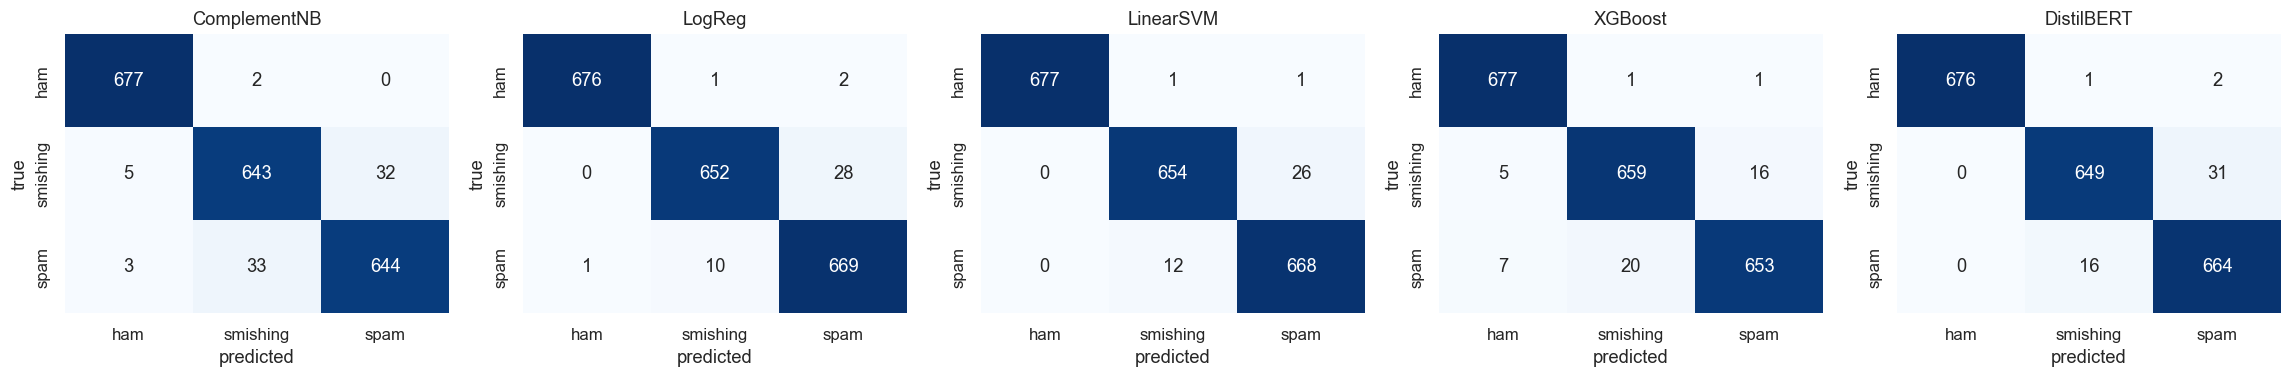

In [16]:
# Confusion matrix per model
n = len(predictions)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.6))
if n == 1: axes = [axes]
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(name); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

## 11. Model comparison

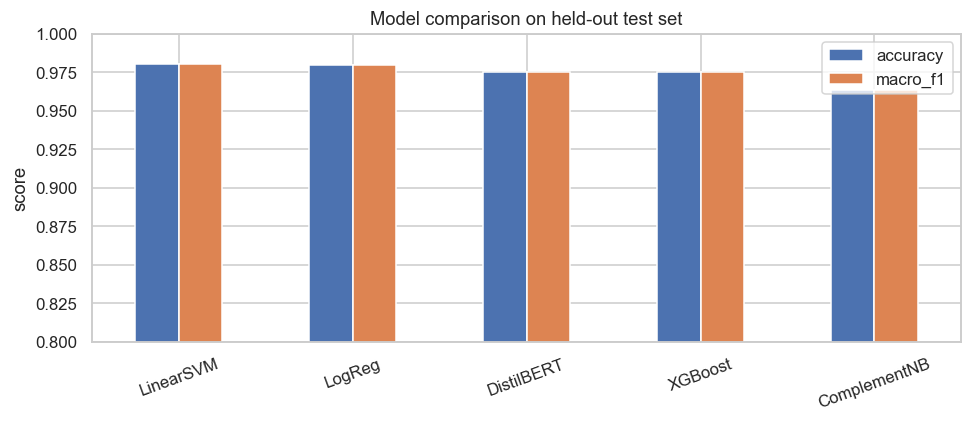

Best model by macro-F1: LinearSVM (0.9804)


In [17]:
ax = results[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(9, 4))
ax.set_title("Model comparison on held-out test set")
ax.set_ylabel("score"); ax.set_ylim(0.8, 1.0); ax.set_xlabel("")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

best_model = results.index[0]
print(f"Best model by macro-F1: {best_model} ({results.loc[best_model, 'macro_f1']:.4f})")

## 12. Error analysis

The interesting failures live in the **Spam vs Smishing** cells of the confusion matrix. We inspect those misclassifications for the best model and read off the most discriminative tokens learned by Logistic Regression for interpretability.

In [18]:
# Spam <-> Smishing confusions for the best model
spam_i, smis_i = LABEL_NAMES.index("spam"), LABEL_NAMES.index("smishing")
best_pred = predictions[best_model]
mask = (((y_test == spam_i) & (best_pred == smis_i)) |
        ((y_test == smis_i) & (best_pred == spam_i)))
err = X_test.loc[mask].copy()
err["true"] = [LABEL_NAMES[i] for i in y_test[mask]]
err["pred"] = [LABEL_NAMES[i] for i in best_pred[mask]]
print(f"{best_model}: {mask.sum()} spam<->smishing confusions out of {len(y_test)} test msgs")
err[["true", "pred", "TEXT"]].head(12)

LinearSVM: 38 spam<->smishing confusions out of 2039 test msgs


,true,pred,TEXT
5414,smishing,spam,free 1st week entry 2 textpod 4 a chance 2 win...
7888,spam,smishing,sms. ac blind date 4u!: rodds1 embody 21/m fro...
1964,smishing,spam,\tFree entry to the gr8prizes wkly comp 4 a ch...
5975,smishing,spam,i'd like to tell you my deepest darkest fantas...
9929,spam,smishing,free entry into our £250 weekly comp just plac...
6108,smishing,spam,"xxxmobilemovieclub: to use your credit, cluck ..."
4348,smishing,spam,behave you want 750 anytime any network mins 1...
5637,smishing,spam,great news! call freefone 08006344447 to claim...
8783,spam,smishing,the current leading bid is 151. to hesitate th...
8296,spam,smishing,the current leading bid is 151. to pause this ...


In [19]:
# Interpretability: top word-TF-IDF tokens per class from the Logistic Regression model
logreg = fitted["LogReg"]
word_vec = logreg.named_steps["features"].named_transformers_["word"]
feat_names = word_vec.get_feature_names_out()
coefs = logreg.named_steps["clf"].coef_           # (n_classes, n_features) incl char+num
word_coefs = coefs[:, :len(feat_names)]           # word block comes first in the ColumnTransformer

for ci, cname in enumerate(LABEL_NAMES):
    top = np.argsort(word_coefs[ci])[-15:][::-1]
    print(f"[{cname}] {', '.join(feat_names[top])}")

[ham] my, me, lt, gt, lt gt, then, it, he, ok, in, good, is, can, was, but
[smishing] __phone__ now, __url__, __phone__, prize, you, reply stop, claim, ingest, your, delivery, please, message, new video, urgent, now or
[spam] only you, ringtone, sms, of video, freemsg, announcement from, premier, from premier, win, or2stoptxt, now or2stoptxt, tone, enjoy, uk, tones


## 13. Conclusion

- **Setup.** The dataset's `URL`/`EMAIL`/`PHONE` flag columns are excluded — every model learns only from the message text (word + char TF-IDF) plus text-derived statistics (length, digit count, uppercase ratio, etc.).
- **Ranking (this run).** Macro-F1 on the held-out test set: **Linear SVM 0.980 ≈ Logistic Regression 0.979 > DistilBERT 0.976 ≈ XGBoost 0.975 > Complement NB 0.963**. Every model clears 0.96 — the dataset is clean, balanced, and lexically well-separated.
- **Classic models win here.** The TF-IDF linear models slightly *edge out* the fine-tuned DistilBERT. This is a legitimate and common outcome for SMS spam: messages are short and keyword-driven, so strong lexical cues (`free`, `claim`, `prize`, `__phone__`) are exactly what bag-of-n-grams captures, while a 3-epoch DistilBERT has no headroom to beat them. The transformer would likely need more epochs / a domain-pretrained checkpoint to pull ahead, at much higher cost.
- **Dropping the flag columns barely mattered.** Removing the explicit `URL`/`EMAIL`/`PHONE` features moved macro-F1 by less than 0.003 for every model. The reason: the same information already reaches the model through the text — raw URLs and phone numbers are normalized to `__url__`/`__phone__` tokens, which the TF-IDF captures. The Logistic Regression coefficients confirm it: the top smishing tokens are led by `__phone__`, `__url__`, `prize`, `claim`, `reply stop`.
- **Where the difficulty is.** Ham is near-perfectly separated by every model (Linear SVM ham F1 ≈ 0.999). Essentially all remaining errors are **Spam ↔ Smishing** (38 of 2,039 test messages for the best model) — both are unsolicited promotional messages, so the boundary is genuinely fuzzy even for humans (see the misclassified examples above).
- **Context from EDA.** Even though the flag columns are not used as features, the EDA shows why smishing is identifiable: 72% of smishing messages contain a phone number vs 39% of spam and ~0% of ham — and that same "phone present" signal reaches the model through the `__phone__` token.
- **Recommendation & trade-offs.** For this dataset **Linear SVM / Logistic Regression is the practical winner**: highest accuracy here, trains in seconds, and is fully interpretable. DistilBERT brought no accuracy gain while requiring a GPU and being opaque.
- **Limitations & next steps.** English-only. Natural extensions: calibrated probabilities for a review queue, threshold tuning for high *recall* on the smishing class (missing a phishing SMS is the costly error), and a two-stage smishing-vs-rest classifier.